<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/AML_RSF_without_risk_group.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 13.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 147.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

In [ ]:
BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/combined_survival_model_ready_wout_protocol/"
)

TRAIN_PATH = (
    BASE_DIR
    / "combined_train_survival_model_ready.csv"
)

VALIDATION_PATH = (
    BASE_DIR
    / "combined_validation_survival_model_ready.csv"
)

TEST_PATH = (
    BASE_DIR
    / "combined_test_survival_model_ready.csv"
)

XAI_OUTPUT_DIR = (
    BASE_DIR
    / "rsf_xai_without_risk_group"
)

XAI_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:")
print(XAI_OUTPUT_DIR)

Output directory:
/content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/rsf_xai_without_risk_group


In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (620, 68)
Validation: (177, 68)
Test: (89, 68)


In [ ]:
DURATION_COL = "OS_DAYS"
EVENT_COL = "OS_EVENT"

PATIENT_ID_COL = "PATIENT_ID"
SAMPLE_ID_COL = "SAMPLE_ID"

EXCLUDED_COLUMNS = [
    PATIENT_ID_COL,
    SAMPLE_ID_COL,
    DURATION_COL,
    EVENT_COL
]

In [ ]:
candidate_features = [
    column
    for column in train_df.columns
    if column not in EXCLUDED_COLUMNS
]

In [ ]:
candidate_features = [
    column
    for column in candidate_features
    if pd.api.types.is_numeric_dtype(
        train_df[column]
    )
]

print(
    "Numeric candidate features:",
    len(candidate_features)
)

Numeric candidate features: 64


In [ ]:
zero_variance_features = [
    feature
    for feature in candidate_features
    if train_df[
        feature
    ].nunique(
        dropna=True
    ) <= 1
]

print(
    "Zero-variance features:",
    len(zero_variance_features)
)

Zero-variance features: 0


In [ ]:
RISK_GROUP_FEATURES = [
    feature
    for feature in candidate_features
    if feature.startswith(
        "RISK_GROUP"
    )
]

print(
    "Risk Group features to remove:"
)

for feature in RISK_GROUP_FEATURES:
    print("-", feature)

Risk Group features to remove:
- RISK_GROUP_CLEAN_High
- RISK_GROUP_CLEAN_Low
- RISK_GROUP_CLEAN_Missing
- RISK_GROUP_CLEAN_Standard


In [ ]:
MODEL_FEATURES = [
    feature
    for feature in candidate_features
    if (
        feature
        not in zero_variance_features
        and
        feature
        not in RISK_GROUP_FEATURES
    )
]

print(
    "\nNumber of model features "
    "without Risk Group:",
    len(MODEL_FEATURES)
)


Number of model features without Risk Group: 60


In [ ]:
assert not any(
    feature.startswith(
        "RISK_GROUP"
    )
    for feature in MODEL_FEATURES
)

print(
    "Risk Group successfully removed."
)

Risk Group successfully removed.


In [ ]:
def prepare_X(df):

    X = df[
        MODEL_FEATURES
    ].copy()

    for feature in MODEL_FEATURES:

        X[
            feature
        ] = pd.to_numeric(
            X[
                feature
            ],
            errors="raise"
        ).astype(float)

    return X

In [ ]:
def prepare_y(df):

    return Surv.from_arrays(
        event=df[
            EVENT_COL
        ]
        .astype(bool)
        .to_numpy(),

        time=df[
            DURATION_COL
        ]
        .astype(float)
        .to_numpy()
    )

In [ ]:
X_train = prepare_X(
    train_df
)

X_validation = prepare_X(
    validation_df
)

X_test = prepare_X(
    test_df
)

y_train = prepare_y(
    train_df
)

y_validation = prepare_y(
    validation_df
)

y_test = prepare_y(
    test_df
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_validation:",
    X_validation.shape
)

print(
    "X_test:",
    X_test.shape
)

X_train: (620, 60)
X_validation: (177, 60)
X_test: (89, 60)


In [ ]:
FINAL_RSF_CONFIG = {
    "n_estimators": 500,
    "max_depth": 6,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "max_features": "sqrt",
    "bootstrap": True,
    "oob_score": True,
    "n_jobs": -1,
    "random_state": 42
}

In [ ]:
rsf_without_risk_group = (
    RandomSurvivalForest(
        **FINAL_RSF_CONFIG
    )
)

rsf_without_risk_group.fit(
    X_train,
    y_train
)

print(
    "RSF without Risk Group fitted."
)

print(
    "OOB C-index:",
    round(
        rsf_without_risk_group.oob_score_,
        4
    )
)

RSF without Risk Group fitted.
OOB C-index: 0.6279


In [ ]:
def get_c_index(
    model,
    X,
    y
):

    risk_scores = (
        model.predict(
            X
        )
    )

    return (
        concordance_index_censored(
            y["event"],
            y["time"],
            risk_scores
        )[0]
    )

In [ ]:
train_cindex = get_c_index(
    rsf_without_risk_group,
    X_train,
    y_train
)

val_cindex = get_c_index(
    rsf_without_risk_group,
    X_validation,
    y_validation
)

test_cindex = get_c_index(
    rsf_without_risk_group,
    X_test,
    y_test
)

print(
    f"Train C-index:      "
    f"{train_cindex:.4f}"
)

print(
    f"Validation C-index: "
    f"{val_cindex:.4f}"
)

print(
    f"Test C-index:       "
    f"{test_cindex:.4f}"
)

Train C-index:      0.7797
Validation C-index: 0.6769
Test C-index:       0.6745


In [ ]:
performance_without_risk = (
    pd.DataFrame({
        "Dataset": [
            "Train",
            "Validation",
            "Test"
        ],

        "C_index": [
            train_cindex,
            val_cindex,
            test_cindex
        ]
    })
)

display(
    performance_without_risk
    .round(3)
)

,Dataset,C_index
0,Train,0.780
1,Validation,0.677
2,Test,0.675


In [ ]:
def survival_cindex_scorer(
    model,
    X,
    y
):

    risk_scores = (
        model.predict(
            X
        )
    )

    return (
        concordance_index_censored(
            y["event"],
            y["time"],
            risk_scores
        )[0]
    )

In [ ]:
perm_results = (
    permutation_importance(
        estimator=rsf_without_risk_group,
        X=X_validation,
        y=y_validation,
        scoring=survival_cindex_scorer,
        n_repeats=50,
        random_state=42,
        n_jobs=-1
    )
)

In [ ]:
importance_df = pd.DataFrame({
    "Feature":
        MODEL_FEATURES,

    "Importance_Mean":
        perm_results.importances_mean,

    "Importance_SD":
        perm_results.importances_std
})

In [ ]:
importance_df[
    "Mean_SD_Ratio"
] = (
    importance_df[
        "Importance_Mean"
    ]
    /
    importance_df[
        "Importance_SD"
    ].replace(
        0,
        np.nan
    )
)

In [ ]:
importance_df = (
    importance_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "Top 20 features "
    "without Risk Group:"
)

display(
    importance_df
    .head(20)
    .round(4)
)

Top 20 features without Risk Group:


,Feature,Importance_Mean,Importance_SD,Mean_SD_Ratio
0,WBC_LOG1P,0.0138,0.0104,1.3203
1,PRIMARY_CYTOGENETIC_CODE_Other,0.0137,0.0084,1.6308
2,RACE_Black or African American,0.0137,0.0130,1.0588
3,T_10_11_P11_2_Q23,0.0109,0.0030,3.5953
4,MONOSOMY_7,0.0081,0.0036,2.2470
5,PERIPHERAL_BLASTS_PERCENTAGE,0.0073,0.0069,1.0523
6,INV_16,0.0067,0.0054,1.2418
7,PRIMARY_CYTOGENETIC_CODE_inv(16),0.0064,0.0062,1.0381
8,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.0060,0.0058,1.0421
9,T_8_21,0.0046,0.0018,2.4798


In [ ]:
importance_df.to_csv(
    XAI_OUTPUT_DIR
    / "rsf_without_risk_group_permutation_importance_validation.csv",
    index=False
)

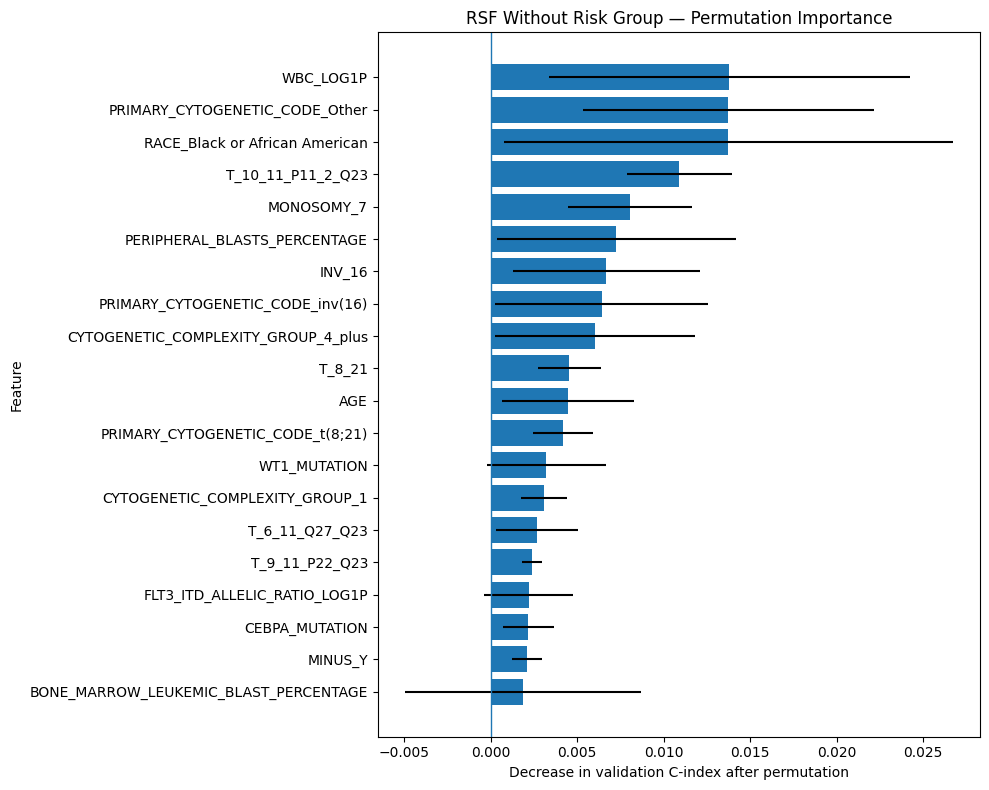

In [ ]:
TOP_N = 20

plot_df = (
    importance_df
    .head(TOP_N)
    .sort_values(
        "Importance_Mean"
    )
)

plt.figure(
    figsize=(
        10,
        8
    )
)

plt.barh(
    plot_df[
        "Feature"
    ],
    plot_df[
        "Importance_Mean"
    ],
    xerr=plot_df[
        "Importance_SD"
    ]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "Decrease in validation C-index "
    "after permutation"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "RSF Without Risk Group — "
    "Permutation Importance"
)

plt.tight_layout()

plt.savefig(
    XAI_OUTPUT_DIR
    / "rsf_without_risk_group_top20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
test_perm_results = (
    permutation_importance(
        estimator=rsf_without_risk_group,
        X=X_test,
        y=y_test,
        scoring=survival_cindex_scorer,
        n_repeats=50,
        random_state=42,
        n_jobs=-1
    )
)

In [ ]:
test_importance_df = (
    pd.DataFrame({
        "Feature":
            MODEL_FEATURES,

        "Test_Importance_Mean":
            test_perm_results
            .importances_mean,

        "Test_Importance_SD":
            test_perm_results
            .importances_std
    })
)

In [ ]:
test_importance_df[
    "Mean_SD_Ratio"
] = (
    test_importance_df[
        "Test_Importance_Mean"
    ]
    /
    test_importance_df[
        "Test_Importance_SD"
    ].replace(
        0,
        np.nan
    )
)

In [ ]:
test_importance_df = (
    test_importance_df
    .sort_values(
        "Test_Importance_Mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "TEST — Top 20 features "
    "without Risk Group:"
)

display(
    test_importance_df
    .head(20)
    .round(4)
)

TEST — Top 20 features without Risk Group:


,Feature,Test_Importance_Mean,Test_Importance_SD,Mean_SD_Ratio
0,PRIMARY_CYTOGENETIC_CODE_Other,0.0365,0.0139,2.6234
1,AGE,0.0248,0.0084,2.9614
2,RACE_Black or African American,0.0217,0.0175,1.2406
3,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,0.0198,0.0117,1.6894
4,INV_16,0.0170,0.0086,1.9742
5,PRIMARY_CYTOGENETIC_CODE_inv(16),0.0148,0.0104,1.4229
6,WBC_LOG1P,0.0122,0.0160,0.7625
7,FAB_M0,0.0113,0.0033,3.4620
8,PERIPHERAL_BLASTS_PERCENTAGE,0.0068,0.0112,0.6116
9,MLL,0.0059,0.0038,1.5685


In [ ]:
test_importance_df.to_csv(
    XAI_OUTPUT_DIR
    / "rsf_without_risk_group_permutation_importance_test.csv",
    index=False
)

In [ ]:
comparison_df = (
    importance_df[
        [
            "Feature",
            "Importance_Mean"
        ]
    ]
    .merge(
        test_importance_df[
            [
                "Feature",
                "Test_Importance_Mean"
            ]
        ],
        on="Feature"
    )
)

In [ ]:
comparison_df[
    "Validation_Rank"
] = (
    comparison_df[
        "Importance_Mean"
    ]
    .rank(
        ascending=False,
        method="average"
    )
)

comparison_df[
    "Test_Rank"
] = (
    comparison_df[
        "Test_Importance_Mean"
    ]
    .rank(
        ascending=False,
        method="average"
    )
)

In [ ]:
spearman_corr, spearman_p = (
    spearmanr(
        comparison_df[
            "Validation_Rank"
        ],
        comparison_df[
            "Test_Rank"
        ]
    )
)

print(
    "Spearman rank correlation:",
    round(
        spearman_corr,
        3
    )
)

print(
    "p-value:",
    spearman_p
)

Spearman rank correlation: 0.394
p-value: 0.0018347030809580977


In [ ]:
TOP_K = 10

top_val = set(
    importance_df
    .head(TOP_K)[
        "Feature"
    ]
)

top_test = set(
    test_importance_df
    .head(TOP_K)[
        "Feature"
    ]
)

intersection = (
    top_val
    &
    top_test
)

union = (
    top_val
    |
    top_test
)

jaccard = (
    len(
        intersection
    )
    /
    len(
        union
    )
)

print(
    "Validation top 10:"
)

print(
    top_val
)

print(
    "\nTest top 10:"
)

print(
    top_test
)

print(
    "\nCommon features:"
)

print(
    intersection
)

print(
    "\nJaccard similarity:",
    round(
        jaccard,
        3
    )
)

Validation top 10:
{'WBC_LOG1P', 'PRIMARY_CYTOGENETIC_CODE_Other', 'RACE_Black or African American', 'MONOSOMY_7', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'T_8_21', 'PERIPHERAL_BLASTS_PERCENTAGE', 'INV_16', 'PRIMARY_CYTOGENETIC_CODE_inv(16)', 'T_10_11_P11_2_Q23'}

Test top 10:
{'MLL', 'WBC_LOG1P', 'PRIMARY_CYTOGENETIC_CODE_Other', 'RACE_Black or African American', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'FAB_M0', 'PERIPHERAL_BLASTS_PERCENTAGE', 'INV_16', 'AGE', 'PRIMARY_CYTOGENETIC_CODE_inv(16)'}

Common features:
{'WBC_LOG1P', 'PRIMARY_CYTOGENETIC_CODE_Other', 'RACE_Black or African American', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'PERIPHERAL_BLASTS_PERCENTAGE', 'INV_16', 'PRIMARY_CYTOGENETIC_CODE_inv(16)'}

Jaccard similarity: 0.538


In [ ]:
baseline_cindex = (
    get_c_index(
        rsf_without_risk_group,
        X_validation,
        y_validation
    )
)

print(
    "Baseline validation C-index:",
    round(
        baseline_cindex,
        4
    )
)

Baseline validation C-index: 0.6769


In [ ]:
TOP_K_VALUES = [
    1,
    3,
    5,
    10,
    15
]

N_REPEATS = 30

rng = np.random.default_rng(
    42
)

ranked_features = (
    importance_df[
        "Feature"
    ]
    .tolist()
)

faithfulness_results = []

In [ ]:
for k in TOP_K_VALUES:

    selected_features = (
        ranked_features[
            :k
        ]
    )

    repeated_cindices = []

    for repeat in range(
        N_REPEATS
    ):

        X_permuted = (
            X_validation.copy()
        )

        for feature in (
            selected_features
        ):

            X_permuted[
                feature
            ] = rng.permutation(
                X_permuted[
                    feature
                ].values
            )

        cindex = (
            get_c_index(
                rsf_without_risk_group,
                X_permuted,
                y_validation
            )
        )

        repeated_cindices.append(
            cindex
        )

    mean_cindex = (
        np.mean(
            repeated_cindices
        )
    )

    sd_cindex = (
        np.std(
            repeated_cindices
        )
    )

    cindex_drop = (
        baseline_cindex
        -
        mean_cindex
    )

    faithfulness_results.append({
        "Top_K_Features_Permuted":
            k,

        "C_Index_Mean":
            mean_cindex,

        "C_Index_SD":
            sd_cindex,

        "C_Index_Drop":
            cindex_drop
    })

In [ ]:
faithfulness_df = (
    pd.DataFrame(
        faithfulness_results
    )
)

baseline_row = (
    pd.DataFrame({
        "Top_K_Features_Permuted":
            [0],

        "C_Index_Mean":
            [baseline_cindex],

        "C_Index_SD":
            [0.0],

        "C_Index_Drop":
            [0.0]
    })
)

faithfulness_df = (
    pd.concat(
        [
            baseline_row,
            faithfulness_df
        ],
        ignore_index=True
    )
)

display(
    faithfulness_df
    .round(3)
)

,Top_K_Features_Permuted,C_Index_Mean,C_Index_SD,C_Index_Drop
0,0,0.677,0.000,0.000
1,1,0.663,0.010,0.014
2,3,0.637,0.023,0.040
3,5,0.616,0.018,0.061
4,10,0.556,0.027,0.121
5,15,0.527,0.027,0.149
6,1,0.664,0.010,0.013
7,3,0.632,0.019,0.045
8,5,0.618,0.027,0.059
9,10,0.565,0.033,0.112


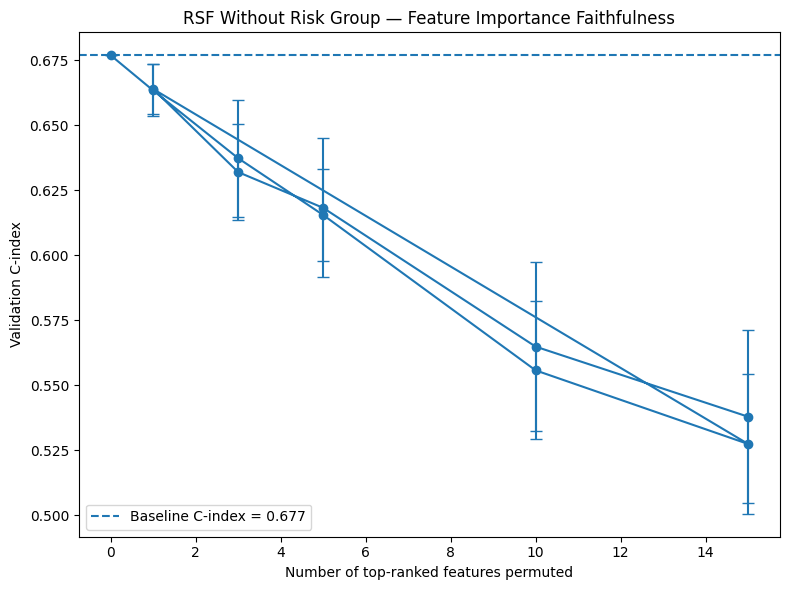

In [ ]:
plt.figure(
    figsize=(
        8,
        6
    )
)

plt.errorbar(
    faithfulness_df[
        "Top_K_Features_Permuted"
    ],
    faithfulness_df[
        "C_Index_Mean"
    ],
    yerr=faithfulness_df[
        "C_Index_SD"
    ],
    marker="o",
    capsize=4
)

plt.axhline(
    baseline_cindex,
    linestyle="--",
    label=(
        f"Baseline C-index = "
        f"{baseline_cindex:.3f}"
    )
)

plt.xlabel(
    "Number of top-ranked "
    "features permuted"
)

plt.ylabel(
    "Validation C-index"
)

plt.title(
    "RSF Without Risk Group — "
    "Feature Importance Faithfulness"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    XAI_OUTPUT_DIR
    / "rsf_without_risk_group_faithfulness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
N_BOOTSTRAPS = 200
N_PERM_REPEATS = 20
RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

n_val = len(
    X_validation
)

bootstrap_importances = []

In [ ]:
for b in range(
    N_BOOTSTRAPS
):

    bootstrap_idx = (
        rng.choice(
            n_val,
            size=n_val,
            replace=True
        )
    )

    X_boot = (
        X_validation
        .iloc[
            bootstrap_idx
        ]
        .reset_index(
            drop=True
        )
    )

    y_boot = (
        y_validation[
            bootstrap_idx
        ]
    )

    boot_perm = (
        permutation_importance(
            estimator=rsf_without_risk_group,
            X=X_boot,
            y=y_boot,
            scoring=survival_cindex_scorer,
            n_repeats=N_PERM_REPEATS,
            random_state=(
                RANDOM_SEED
                +
                b
            ),
            n_jobs=-1
        )
    )

    bootstrap_importances.append(
        boot_perm.importances_mean
    )

    if (
        b + 1
    ) % 20 == 0:

        print(
            f"Completed "
            f"{b + 1}/"
            f"{N_BOOTSTRAPS}"
        )

Completed 20/200
Completed 40/200
Completed 60/200
Completed 80/200
Completed 100/200
Completed 120/200
Completed 140/200


In [ ]:
bootstrap_importances = (
    np.asarray(
        bootstrap_importances
    )
)

print(
    "Bootstrap matrix shape:",
    bootstrap_importances.shape
)

In [ ]:
ci_lower = np.percentile(
    bootstrap_importances,
    2.5,
    axis=0
)

ci_upper = np.percentile(
    bootstrap_importances,
    97.5,
    axis=0
)

In [ ]:
importance_ci_df = (
    pd.DataFrame({
        "Feature":
            MODEL_FEATURES,

        "Importance_Mean":
            perm_results
            .importances_mean,

        "Importance_SD":
            perm_results
            .importances_std,

        "CI_2.5%":
            ci_lower,

        "CI_97.5%":
            ci_upper
    })
)

In [ ]:
importance_ci_df = (
    importance_ci_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print(
    "RSF Without Risk Group — "
    "Permutation Importance "
    "with Bootstrap 95% CIs"
)

display(
    importance_ci_df
    .head(20)
    .round(4)
)

In [ ]:
importance_ci_df[
    "CI_Excludes_Zero"
] = (
    importance_ci_df[
        "CI_2.5%"
    ] > 0
)

display(
    importance_ci_df
    .head(20)
    .round(4)
)

In [ ]:
importance_ci_df.to_csv(
    XAI_OUTPUT_DIR
    / "rsf_without_risk_group_importance_bootstrap_ci.csv",
    index=False
)

In [ ]:
top20 = (
    importance_ci_df
    .head(20)
    .copy()
    .iloc[
        ::-1
    ]
)

lower_error = (
    top20[
        "Importance_Mean"
    ]
    -
    top20[
        "CI_2.5%"
    ]
).clip(
    lower=0
)

upper_error = (
    top20[
        "CI_97.5%"
    ]
    -
    top20[
        "Importance_Mean"
    ]
).clip(
    lower=0
)

plt.figure(
    figsize=(
        10,
        8
    )
)

plt.errorbar(
    top20[
        "Importance_Mean"
    ],
    top20[
        "Feature"
    ],
    xerr=[
        lower_error,
        upper_error
    ],
    fmt="o",
    capsize=4
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Permutation Importance "
    "(C-index decrease)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "RSF Without Risk Group — "
    "Permutation Importance "
    "with 95% Bootstrap CIs"
)

plt.tight_layout()

plt.savefig(
    XAI_OUTPUT_DIR
    / "rsf_without_risk_group_bootstrap_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print(
    "PERFORMANCE"
)

display(
    performance_without_risk
    .round(3)
)


print(
    "\nTOP 15 VALIDATION FEATURES"
)

display(
    importance_df[
        [
            "Feature",
            "Importance_Mean",
            "Importance_SD",
            "Mean_SD_Ratio"
        ]
    ]
    .head(15)
    .round(4)
)


print(
    "\nTOP 15 FEATURES "
    "WITH BOOTSTRAP CIs"
)

display(
    importance_ci_df[
        [
            "Feature",
            "Importance_Mean",
            "CI_2.5%",
            "CI_97.5%"
        ]
    ]
    .head(15)
    .round(4)
)


print(
    "\nFAITHFULNESS"
)

display(
    faithfulness_df
    .round(3)
)


print(
    "\nVALIDATION / TEST STABILITY"
)

print(
    "Spearman rho:",
    round(
        spearman_corr,
        3
    )
)

print(
    "Spearman p:",
    spearman_p
)

print(
    "Top-10 Jaccard:",
    round(
        jaccard,
        3
    )
)